In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
from PIL import Image
import numpy as np

In [10]:
import zipfile
import os
import cv2

zip_path = "/content/archive (21).zip"
extract_path = "/content/extracted_images"

# Extract the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Read all images
images = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith(tuple([".jpg", ".jpeg", ".png", ".bmp"])): # Use tuple for multiple endings
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is not None:
                images.append(img)

print("Total images loaded before resizing:", len(images))

# Resize all images
resized_images = []
for img in images:
    resized_img = cv2.resize(img, (224, 224)) # Resize to 224x224
    resized_images.append(resized_img)

images = resized_images # Replace original images with resized ones

print("Total images loaded and resized:", len(images))

Total images loaded before resizing: 506
Total images loaded and resized: 506


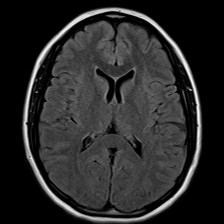

In [11]:
from PIL import Image as PilImage # Import Image from PIL with an alias

# Assuming you want to work with the first image from the 'images' list
# Convert the OpenCV image (numpy array) to a PIL Image object first
image = PilImage.fromarray(images[0])

image_resized = image.resize((224,224))
image
image_resized

In [12]:
# Convert all images from BGR to RGB
rgb_images = []
for img in images:
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    rgb_images.append(rgb_img)

images = rgb_images # Replace original images with RGB ones

print("All images converted to RGB format.")

All images converted to RGB format.


In [13]:
# Normalize pixel values to be between 0 and 1
# Convert images to float32 first for division
normalized_images = []
for img in images:
    normalized_img = img.astype(np.float32) / 255.0
    normalized_images.append(normalized_img)

images = normalized_images # Replace original images with normalized ones

print("All images normalized to 0-1 range.")

All images normalized to 0-1 range.


In [14]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Convert the list of numpy arrays to a single numpy array for ImageDataGenerator
images_array = np.array(images)

# Define the ImageDataGenerator for augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

print("ImageDataGenerator for data augmentation has been set up.")

ImageDataGenerator for data augmentation has been set up.


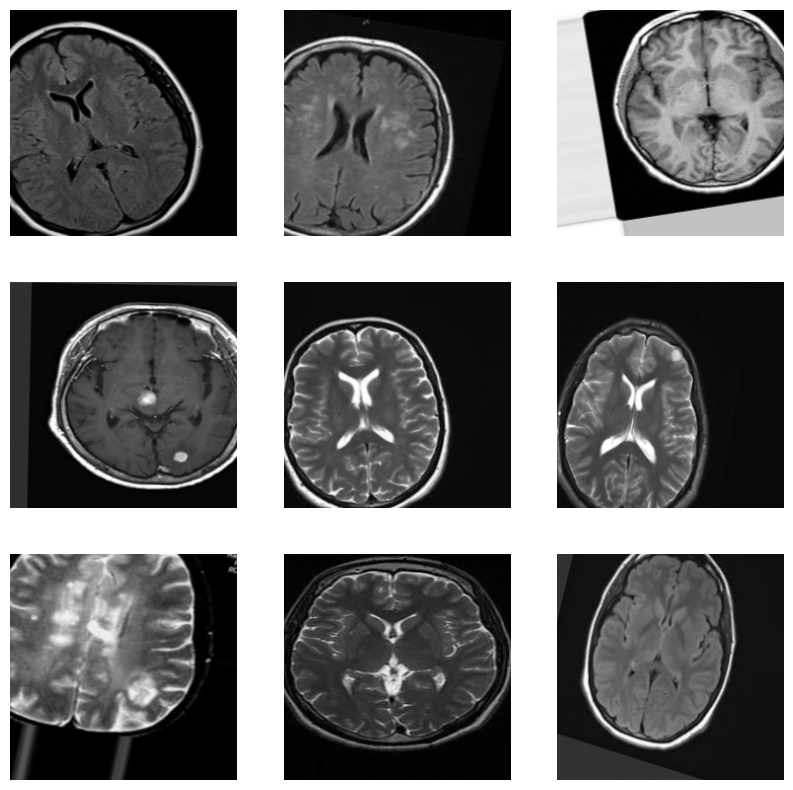

In [15]:
# Example of generating and displaying augmented images
plt.figure(figsize=(10, 10))
for i, (img_augmented, _) in enumerate(datagen.flow(images_array, np.zeros(len(images_array)), batch_size=1, shuffle=False)):
    if i >= 9: # Display 9 augmented images
        break
    plt.subplot(3, 3, i + 1)
    plt.imshow(img_augmented[0])
    plt.axis('off')
plt.show()

In [16]:
import numpy as np

# Flatten the images_array
# images_array shape is (num_images, height, width, channels)
# Reshape to (num_images, height * width * channels)
flattened_images = images_array.reshape(images_array.shape[0], -1)

print(f"Original images_array shape: {images_array.shape}")
print(f"Flattened images shape: {flattened_images.shape}")

Original images_array shape: (506, 224, 224, 3)
Flattened images shape: (506, 150528)


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Re-read image paths to get labels
image_paths = []
labels = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith(tuple([".jpg", ".jpeg", ".png", ".bmp"])): # Use tuple for multiple endings
            img_path = os.path.join(root, file)
            image_paths.append(img_path)
            if 'no' in root.lower():
                labels.append(0) # Label 0 for 'no' tumor
            elif 'yes' in root.lower():
                labels.append(1) # Label 1 for 'yes' tumor

# Ensure the order of labels matches the order of images in 'flattened_images'
# This requires re-loading images in the same order as flattened_images was created.
# Given the current notebook state, `images` was constructed by walking the directory,
# so `image_paths` constructed similarly should align.

# Convert labels to a numpy array
y = np.array(labels)

# Assign features (X) from the flattened images
X = flattened_images

print(f"Number of features (X): {X.shape}")
print(f"Number of labels (y): {y.shape}")
print(f"Example labels: {y[:10]}")

Number of features (X): (506, 150528)
Number of labels (y): (506,)
Example labels: [0 0 0 0 0 0 0 0 0 0]


In [18]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (404, 150528)
X_test shape: (102, 150528)
y_train shape: (404,)
y_test shape: (102,)


In [19]:
# Initialize and train the Logistic Regression model
# Using a small max_iter to prevent long training times, consider increasing for better performance
logistic_model = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')
logistic_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = logistic_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Logistic Regression Model Accuracy: {accuracy:.4f}")

Logistic Regression Model Accuracy: 1.0000


In [20]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier model
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = random_forest_model.predict(X_test)

# Calculate accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Classifier Model Accuracy: {accuracy_rf:.4f}")

Random Forest Classifier Model Accuracy: 0.9804


In [21]:
from sklearn.svm import SVC

# Initialize and train the Support Vector Machine model
# Using a small subset of the data or a linear kernel for faster training given the high dimensionality
# For better performance on real data, more extensive hyperparameter tuning would be needed.
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test)

# Calculate accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print(f"Support Vector Machine Model Accuracy: {accuracy_svm:.4f}")

Support Vector Machine Model Accuracy: 0.9804


Classification Report for SVM Model:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        40
           1       1.00      0.97      0.98        62

    accuracy                           0.98       102
   macro avg       0.98      0.98      0.98       102
weighted avg       0.98      0.98      0.98       102



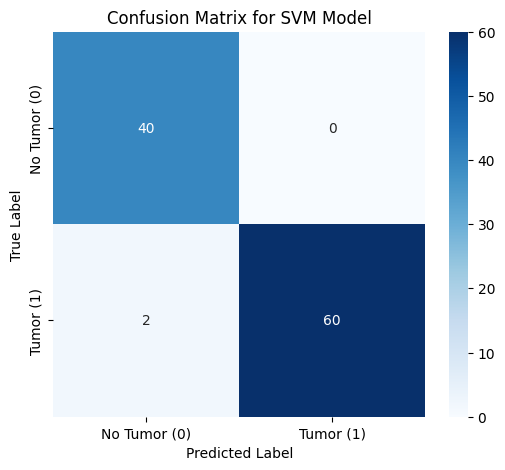

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Classification Report
print("Classification Report for SVM Model:")
print(classification_report(y_test, y_pred_svm))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Tumor (0)', 'Tumor (1)'],
            yticklabels=['No Tumor (0)', 'Tumor (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for SVM Model')
plt.show()

The prediction for the uploaded image is: Tumor


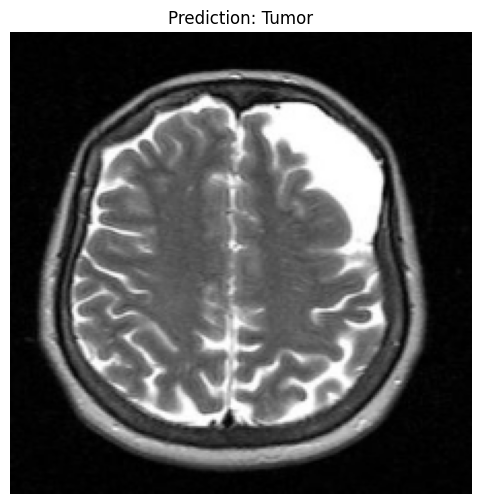

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# Removed: from skimage.feature import hog (as HOG is not used for SVM prediction here)

# Define the image processing function to match SVM training preprocessing
def process_and_predict_image(image_path, model, target_size=(224, 224)):
    # 1. Load the image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}. Please check the path and ensure the image exists.")
        return None, None # Return None for processed_image as well

    # 2. Resize the image to the target_size (width, height)
    resized_img = cv2.resize(img, target_size)

    # 3. Convert from BGR to RGB (OpenCV reads in BGR, original training data was converted to RGB)
    rgb_img = cv2.cvtColor(resized_img, cv2.COLOR_BGR2RGB)

    # 4. Normalize pixel values to be between 0 and 1
    normalized_img = rgb_img.astype(np.float32) / 255.0

    # 5. Flatten the image array to match the input shape of the SVM model
    # The original SVM was trained on flattened (224, 224, 3) images -> 150528 features
    flattened_img = normalized_img.reshape(1, -1) # Reshape for a single sample prediction

    # 6. Make prediction
    prediction = model.predict(flattened_img)

    # Return the prediction and the RGB normalized image for display
    return prediction[0], normalized_img # Return normalized_img for display

# --- Use the function with your uploaded image --- #

# IMPORTANT: Replace '/content/your_uploaded_image.jpg' with the actual path to your image
new_image_path = '/content/extracted_images/yes/Y115.JPG' # <--- UPDATE THIS PATH

# Perform prediction
prediction_result, processed_image_for_display = process_and_predict_image(new_image_path, svm_model)

if prediction_result is not None:
    label = 'Tumor' if prediction_result == 1 else 'No Tumor'
    print(f"The prediction for the uploaded image is: {label}")

    # Display the processed image with its prediction
    plt.figure(figsize=(6, 6))
    plt.imshow(processed_image_for_display) # imshow handles (H, W, C) for RGB
    plt.title(f'Prediction: {label}')
    plt.axis('off')
    plt.show()
else:
    print("Prediction could not be made due to an error in loading or processing the image. Please check the image path and file.")